In [5]:
import pandas as pd

df = pd.read_csv("/content/Final_MasterDataset.csv")


print("Total rows:", len(df))
print("\nMissing values per column:")
print(df.isna().sum())


Total rows: 155

Missing values per column:
Country                                                                       0
Year                                                                          0
D_Expenditure_GDP                                                             0
Conflict_Intensity                                                          155
Health_Expenditure_(% of GDP)                                                39
Education_Expenditure_(% of GDP)                                             30
Environmental_impact(CO2e/capita)                                             5
PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)\n      0
Refugees                                                                      0
Asylum Seekers                                                                0
Total number of deaths                                                        0
Population                                                                  

In [6]:
df = df.dropna(subset=["Environmental_impact(CO2e/capita)"])

print("Rows after dropping missing target:", len(df))



Rows after dropping missing target: 150


In [8]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

TARGET = "Environmental_impact(CO2e/capita)"
FEATURES = ["Country", "Year", "D_Expenditure_GDP"]

# Time split (your choice)
train_df = df[df["Year"] <= 2017].copy()
test_df  = df[df["Year"] > 2017].copy()

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

# Preprocess: one-hot encode country, pass numeric as-is (RF doesn't need scaling)
cat_features = ["Country"]
num_features = ["Year", "D_Expenditure_GDP"]

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipe, cat_features),
        ("num", numeric_pipe, num_features),
    ]
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=2,      # helps reduce overfitting on small data
    max_features="sqrt"
)

model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", rf)
])

# Train
model_rf.fit(X_train, y_train)

# Predict
y_pred = model_rf.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))

Random Forest Results
MAE : 1.4148
RMSE: 1.6203
R2  : 0.8466


In [13]:
def predict_co2(country: str, year: int, military_percent: float) -> float:
    """
    Predict Environmental_impact(CO2e/capita) using the trained model_rf.
    Inputs:
      - country: e.g., "USA", "CHN", "RUS", "GBR", "FRA"
      - year: e.g., 2025
      - military_percent: D_Expenditure_GDP as percentage value (e.g., 3.4 means 3.4%)
    """
    input_df = pd.DataFrame({
        "Country": [country],
        "Year": [int(year)],
        "D_Expenditure_GDP": [float(military_percent)]
    })
    return float(model_rf.predict(input_df)[0])

In [14]:
print(predict_co2("USA", 2023, 3.4))
print(predict_co2("CHN", 2025, 2.0))

15.847518187457629
6.384157552217786


In [15]:
import pickle
import numpy as np
import h5py

def save_model_to_h5(model, h5_path="rf_co2_model.h5"):
    """
    Saves a sklearn model/pipeline into an HDF5 (.h5) file by storing pickled bytes.
    """
    model_bytes = pickle.dumps(model)
    with h5py.File(h5_path, "w") as f:
        f.create_dataset("sklearn_pipeline_pickle", data=np.void(model_bytes))
        f.attrs["saved_format"] = "sklearn_pickle_inside_hdf5"
    print(f"Saved model to {h5_path}")

def load_model_from_h5(h5_path="rf_co2_model.h5"):
    """
    Loads a sklearn model/pipeline from an HDF5 (.h5) file saved by save_model_to_h5.
    """
    with h5py.File(h5_path, "r") as f:
        model_bytes = bytes(f["sklearn_pipeline_pickle"][()])
    model = pickle.loads(model_bytes)
    print(f"Loaded model from {h5_path}")
    return model

In [16]:
save_model_to_h5(model_rf, "rf_co2_model.h5")

Saved model to rf_co2_model.h5


In [17]:
loaded_model = load_model_from_h5("rf_co2_model.h5")

# test prediction with loaded model
test_input = pd.DataFrame({"Country":["USA"], "Year":[2023], "D_Expenditure_GDP":[3.4]})
print(float(loaded_model.predict(test_input)[0]))

Loaded model from rf_co2_model.h5
15.847518187457629


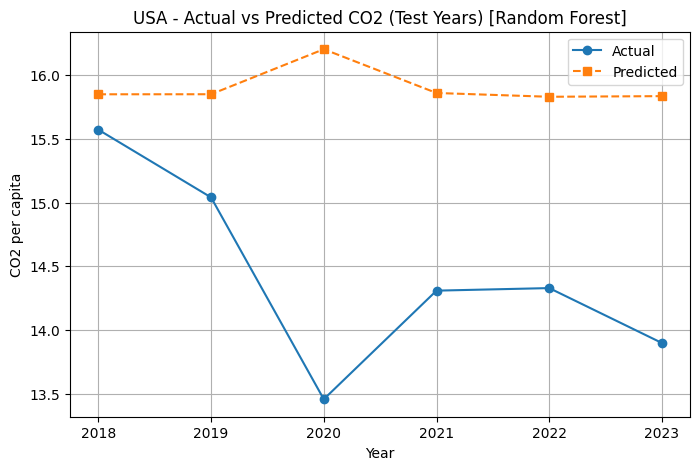

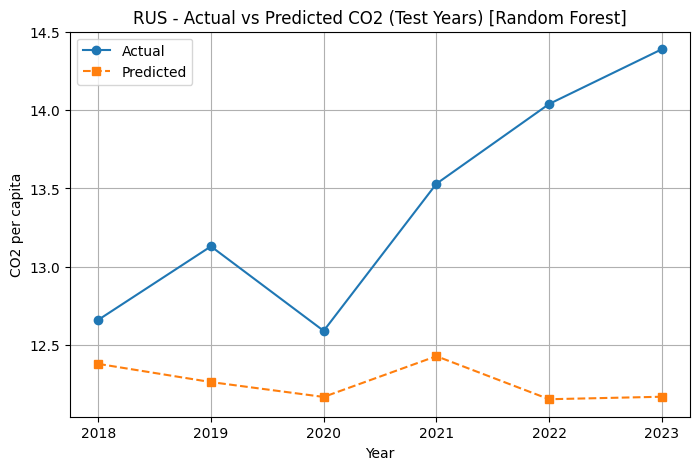

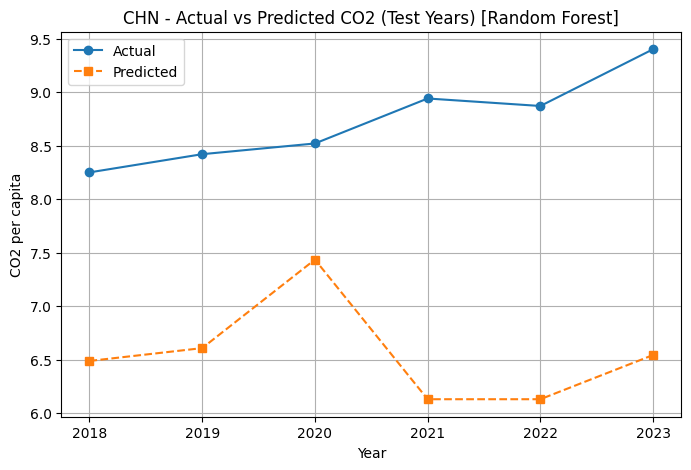

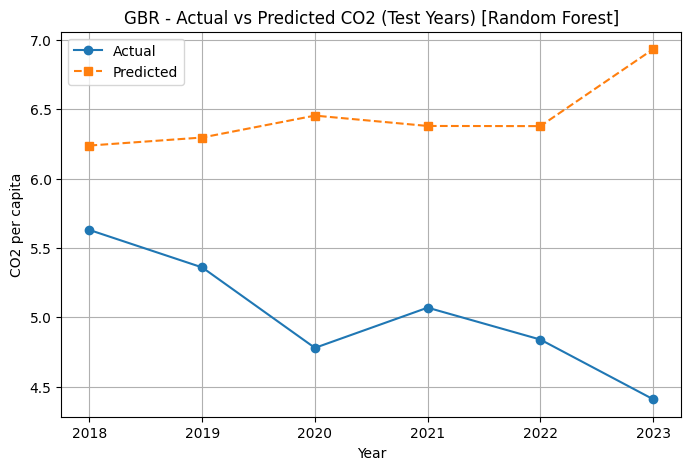

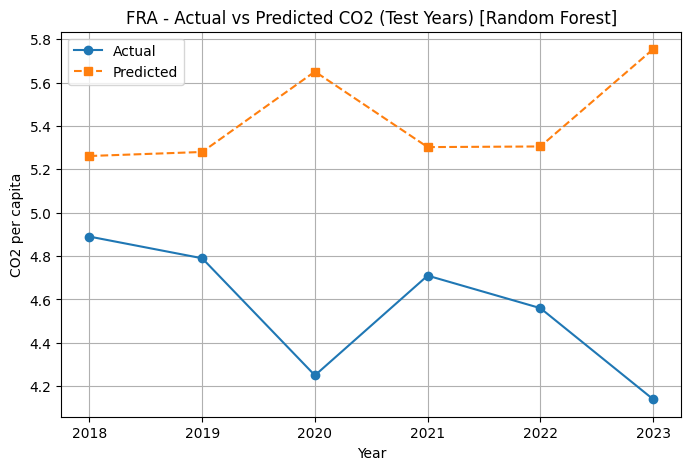

In [9]:
import matplotlib.pyplot as plt

results = test_df.copy()
results["Predicted_CO2"] = y_pred

for country in results["Country"].unique():
    subset = results[results["Country"] == country]

    plt.figure(figsize=(8,5))
    plt.plot(subset["Year"], subset[TARGET], marker='o', label="Actual")
    plt.plot(subset["Year"], subset["Predicted_CO2"], marker='s', linestyle='--', label="Predicted")

    plt.title(f"{country} - Actual vs Predicted CO2 (Test Years) [Random Forest]")
    plt.xlabel("Year")
    plt.ylabel("CO2 per capita")
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Attach predictions to test set for country-wise evaluation
eval_df = test_df[["Country", "Year"]].copy()
eval_df["Actual"] = y_test.values
eval_df["Predicted"] = y_pred

print("\n===== Random Forest Evaluation (per country, test only) =====")
for country, g in eval_df.groupby("Country"):
    mae_c = mean_absolute_error(g["Actual"], g["Predicted"])
    rmse_c = np.sqrt(mean_squared_error(g["Actual"], g["Predicted"]))
    r2_c = r2_score(g["Actual"], g["Predicted"])
    print(f"{country:>3} | n={len(g):2d} | MAE={mae_c:.4f} | RMSE={rmse_c:.4f} | R2={r2_c:.4f}")


===== Random Forest Evaluation (per country, test only) =====
CHN | n= 6 | MAE=2.1760 | RMSE=2.2761 | R2=-34.1983
FRA | n= 6 | MAE=0.8692 | RMSE=0.9877 | R2=-11.8155
GBR | n= 6 | MAE=1.4316 | RMSE=1.5543 | R2=-14.2244
RUS | n= 6 | MAE=1.1301 | RMSE=1.3366 | R2=-2.9955
USA | n= 6 | MAE=1.4671 | RMSE=1.6638 | R2=-4.6924


In [11]:
mae_all = mean_absolute_error(eval_df["Actual"], eval_df["Predicted"])
rmse_all = np.sqrt(mean_squared_error(eval_df["Actual"], eval_df["Predicted"]))
r2_all = r2_score(eval_df["Actual"], eval_df["Predicted"])
print(f"\nALL | n={len(eval_df):2d} | MAE={mae_all:.4f} | RMSE={rmse_all:.4f} | R2={r2_all:.4f}")


ALL | n=30 | MAE=1.4148 | RMSE=1.6203 | R2=0.8466


In [12]:
# Extract feature names
feature_names = model_rf.named_steps["preprocessor"].get_feature_names_out()

importances = model_rf.named_steps["regressor"].feature_importances_

for name, importance in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name}: {importance:.4f}")

num__D_Expenditure_GDP: 0.3868
cat__Country_USA: 0.3398
cat__Country_CHN: 0.0851
cat__Country_RUS: 0.0622
cat__Country_FRA: 0.0522
num__Year: 0.0499
cat__Country_GBR: 0.0241
